In [26]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import psycopg
from dotenv import load_dotenv

load_dotenv()

sys.path.append("../src")

pd.set_option("display.max_columns", None)

In [27]:
connection = psycopg.connect(
    host=os.getenv("POSTGRES_HOST"),
    port=os.getenv("POSTGRES_PORT"),
    dbname=os.getenv("POSTGRES_DB"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
)

print("Connected to PostgreSQL")

Connected to PostgreSQL


In [28]:
load_query = """
SELECT
    date,
    period,
    net_load_mwh,
    crete_flow_mwh
FROM system_load
ORDER BY date, period;
"""

res_query = """
SELECT
    date,
    period,
    res_mwh
FROM res_production
ORDER BY date, period;
"""

system_load = pd.read_sql(
    load_query,
    connection,
)

res = pd.read_sql(
    res_query,
    connection,
)
system_load["date"] = pd.to_datetime(system_load["date"])
res["date"] = pd.to_datetime(res["date"])

print("System Load:", system_load.shape)
print("RES:", res.shape)

System Load: (33475, 4)
RES: (33475, 3)


/var/folders/hl/r1nrlw8d6g54vkvsmknwfw7h0000gn/T/ipykernel_43572/1213459481.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  system_load = pd.read_sql(
/var/folders/hl/r1nrlw8d6g54vkvsmknwfw7h0000gn/T/ipykernel_43572/1213459481.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql(


In [29]:
display(system_load.head())
display(res.head())

print(
    "System Load:",
    system_load["date"].min(),
    "→",
    system_load["date"].max(),
)

print(
    "RES:",
    res["date"].min(),
    "→",
    res["date"].max(),
)

,date,period,net_load_mwh,crete_flow_mwh
0,2023-01-01,1,4190.0,-28.0
1,2023-01-01,2,3961.0,-17.0
2,2023-01-01,3,3794.0,-3.0
3,2023-01-01,4,3585.0,-1.0
4,2023-01-01,5,3449.0,9.0


,date,period,res_mwh
0,2023-01-01,1,415.0
1,2023-01-01,2,457.0
2,2023-01-01,3,504.0
3,2023-01-01,4,580.0
4,2023-01-01,5,642.0


System Load: 2023-01-01 00:00:00 → 2026-08-31 00:00:00
RES: 2023-01-01 00:00:00 → 2026-08-31 00:00:00


In [30]:
display(system_load.head())
display(res.head())

print(
    "System Load:",
    system_load["date"].min(),
    "→",
    system_load["date"].max(),
)

print(
    "RES:",
    res["date"].min(),
    "→",
    res["date"].max(),
)

,date,period,net_load_mwh,crete_flow_mwh
0,2023-01-01,1,4190.0,-28.0
1,2023-01-01,2,3961.0,-17.0
2,2023-01-01,3,3794.0,-3.0
3,2023-01-01,4,3585.0,-1.0
4,2023-01-01,5,3449.0,9.0


,date,period,res_mwh
0,2023-01-01,1,415.0
1,2023-01-01,2,457.0
2,2023-01-01,3,504.0
3,2023-01-01,4,580.0
4,2023-01-01,5,642.0


System Load: 2023-01-01 00:00:00 → 2026-08-31 00:00:00
RES: 2023-01-01 00:00:00 → 2026-08-31 00:00:00


In [20]:
period_counts = (
    system_load
    .groupby("date")["period"]
    .count()
    .value_counts()
    .sort_index()
)

period_counts

period
25    1339
Name: count, dtype: int64

In [21]:
system_load["period"].value_counts().sort_index()

period
1     1339
2     1339
3     1339
4     1339
5     1339
6     1339
7     1339
8     1339
9     1339
10    1339
11    1339
12    1339
13    1339
14    1339
15    1339
16    1339
17    1339
18    1339
19    1339
20    1339
21    1339
22    1339
23    1339
24    1339
25    1339
Name: count, dtype: int64

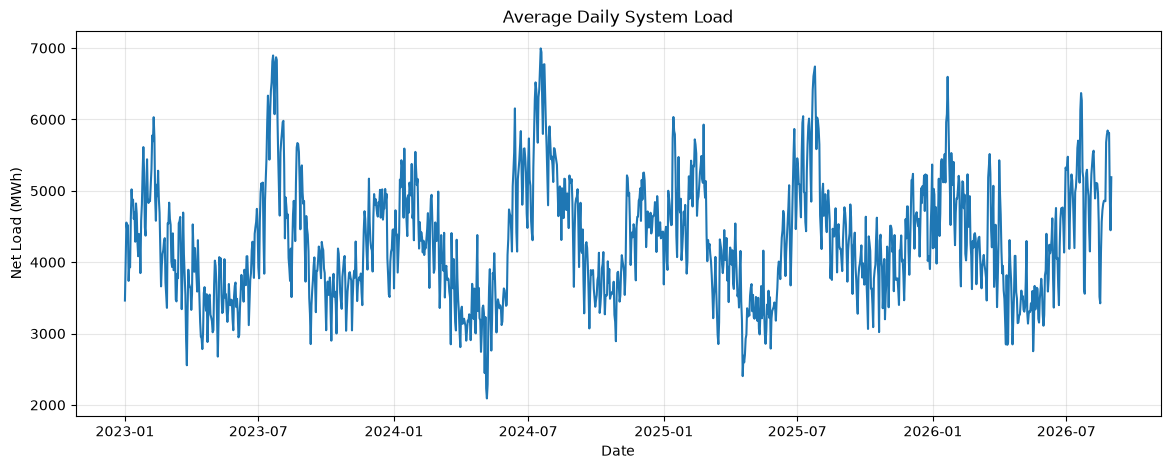

In [22]:
daily_load = (
    system_load
    .groupby("date")["net_load_mwh"]
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_load.index,
    daily_load.values,
)

plt.title("Average Daily System Load")
plt.xlabel("Date")
plt.ylabel("Net Load (MWh)")
plt.grid(alpha=0.3)

plt.show()

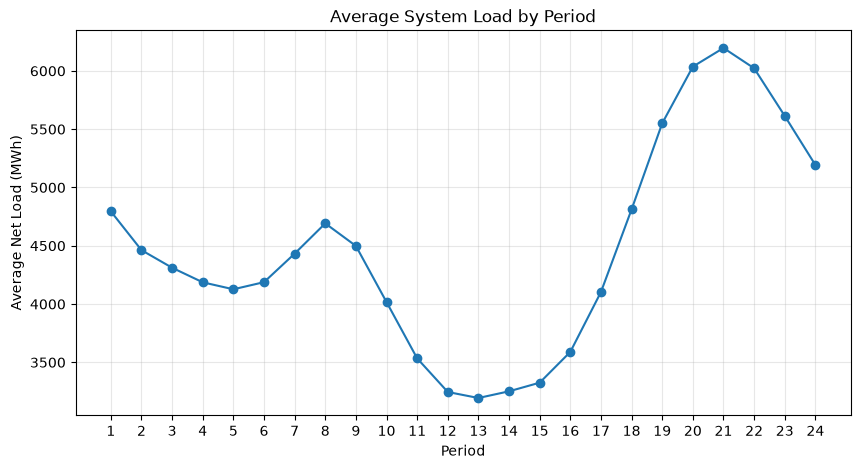

In [23]:
hourly_pattern = (
    system_load[
        system_load["period"] <= 24
    ]
    .groupby("period")["net_load_mwh"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o",
)

plt.title("Average System Load by Period")
plt.xlabel("Period")
plt.ylabel("Average Net Load (MWh)")
plt.xticks(range(1, 25))
plt.grid(alpha=0.3)

plt.show()

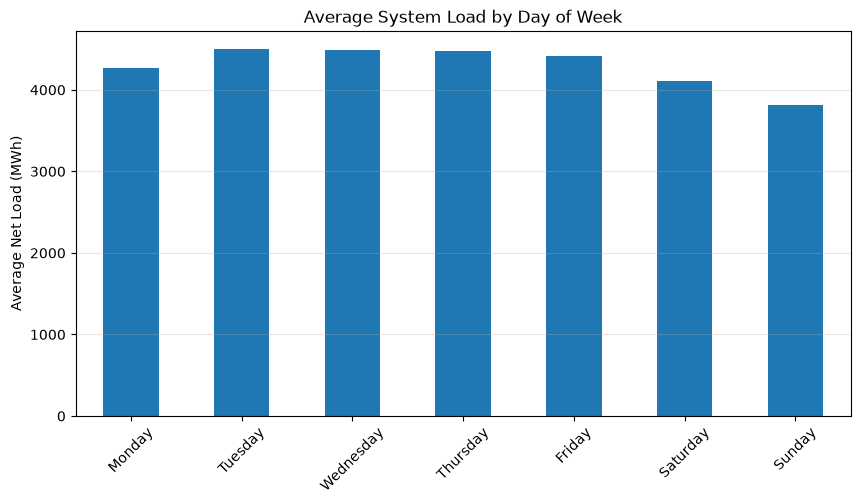

In [24]:
system_load["date"] = pd.to_datetime(
    system_load["date"]
)

system_load["day_of_week"] = (
    system_load["date"].dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_load = (
    system_load
    .groupby("day_of_week")["net_load_mwh"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(10, 5))

weekday_load.plot(
    kind="bar"
)

plt.title("Average System Load by Day of Week")
plt.xlabel("")
plt.ylabel("Average Net Load (MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [25]:

system_load["date"] = pd.to_datetime(system_load["date"])
res["date"] = pd.to_datetime(res["date"])

print(system_load["date"].dtype)
print(res["date"].dtype)
energy = system_load.merge(
    res,
    on=["date", "period"],
    how="inner",
)

print(energy.shape)

display(energy.head())

datetime64[s]
datetime64[s]
(33475, 6)


,date,period,net_load_mwh,crete_flow_mwh,day_of_week,res_mwh
0,2023-01-01,1,4190.0,-28.0,Sunday,415.0
1,2023-01-01,2,3961.0,-17.0,Sunday,457.0
2,2023-01-01,3,3794.0,-3.0,Sunday,504.0
3,2023-01-01,4,3585.0,-1.0,Sunday,580.0
4,2023-01-01,5,3449.0,9.0,Sunday,642.0


In [31]:
period_25 = system_load[
    system_load["period"] == 25
][
    ["date", "period", "net_load_mwh", "crete_flow_mwh"]
]

display(period_25.head(20))

print(period_25["net_load_mwh"].describe())
print()

print(
    "Period 25 equal to zero:",
    (period_25["net_load_mwh"] == 0).sum(),
    "/",
    len(period_25),
)

,date,period,net_load_mwh,crete_flow_mwh
24,2023-01-01,25,0.0,0.0
49,2023-01-02,25,0.0,0.0
74,2023-01-03,25,0.0,0.0
99,2023-01-04,25,0.0,0.0
124,2023-01-05,25,0.0,0.0
149,2023-01-06,25,0.0,0.0
174,2023-01-07,25,0.0,0.0
199,2023-01-08,25,0.0,0.0
224,2023-01-09,25,0.0,0.0
249,2023-01-10,25,0.0,0.0


count    1339.000000
mean        9.297984
std       196.222648
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      4215.000000
Name: net_load_mwh, dtype: float64

Period 25 equal to zero: 1335 / 1339


In [32]:
display(
    system_load[
        system_load["date"] == system_load["date"].min()
    ]
)


,date,period,net_load_mwh,crete_flow_mwh
0,2023-01-01,1,4190.0,-28.0
1,2023-01-01,2,3961.0,-17.0
2,2023-01-01,3,3794.0,-3.0
3,2023-01-01,4,3585.0,-1.0
4,2023-01-01,5,3449.0,9.0
5,2023-01-01,6,3449.0,13.0
6,2023-01-01,7,3513.0,8.0
7,2023-01-01,8,3621.0,-1.0
8,2023-01-01,9,3473.0,-9.0
9,2023-01-01,10,3059.0,-18.0


In [33]:
p25_nonzero = system_load[
    (system_load["period"] == 25)
    & (system_load["net_load_mwh"] != 0)
]

display(p25_nonzero)

print(
    "Non-zero period 25 rows:",
    len(p25_nonzero)
)



,date,period,net_load_mwh,crete_flow_mwh
7549,2023-10-29,25,4131.0,-120.0
16649,2024-10-27,25,4215.0,-136.0
25749,2025-10-26,25,4099.0,-87.0
31824,2026-06-26,25,5.0,0.0


Non-zero period 25 rows: 4
